In [1]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 33.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 45.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 57.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 61.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 57.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]9/10 [seaborn]ib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()          

In [4]:
import seaborn as sns
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
sns.set_theme()   # safe seaborn setup for matplotlib

# ML / DL imports
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgboost
import tensorflow as tf
from tensorflow.keras import layers, models

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
items = pd.read_csv('items.csv')
restaurants = pd.read_csv('resturants.csv')
items.head()

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


In [ ]:
# Load sales.csv 
sales_iter = pd.read_csv('sales.csv', parse_dates=['date'], chunksize=500000)
sales = pd.concat(sales_iter, ignore_index=True)
sales['date'] = pd.to_datetime(sales['date'])
sales.head()

,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


In [ ]:
# Quick shape and null checks
print('items', items.shape, 'restaurants', restaurants.shape, 'sales', sales.shape)
print(sales.isna().sum())


items (100, 5) restaurants (6, 2) sales (109600, 4)
date          0
item_id       0
price         0
item_count    0
dtype: int64


In [ ]:
# Merge sales with items and restaurants
# sales has item_id column named 'item_id' or 'item' depending on file
if 'item_id' in sales.columns:
    sales = sales.rename(columns={'item_id':'item_id'})
elif 'item' in sales.columns:
    sales = sales.rename(columns={'item':'item_id'})

df = sales.merge(items, left_on='item_id', right_on='id', how='left', suffixes=('','_item'))
df = df.merge(restaurants, left_on='store_id', right_on='id', how='left', suffixes=('','_store'))
# compute sales amount
df['sales_amount'] = df['price'] * df['item_count']
# datetime features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter
df['date_only'] = df['date'].dt.date
df.head()



,date,item_id,price,item_count,id,store_id,name,kcal,cost,id_store,name_store,sales_amount,year,month,day,dayofweek,quarter,date_only
0,2019-01-01,3,29.22,2.0,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner,58.44,2019,1,1,1,1,2019-01-01
1,2019-01-01,4,26.42,22.0,4,1,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner,581.24,2019,1,1,1,1,2019-01-01
2,2019-01-01,12,4.87,7.0,12,1,Fantastic Sweet Cola,478,4.87,1,Bob's Diner,34.09,2019,1,1,1,1,2019-01-01
3,2019-01-01,13,4.18,12.0,13,1,Sweet Frozen Soft Drink,490,4.18,1,Bob's Diner,50.16,2019,1,1,1,1,2019-01-01
4,2019-01-01,16,3.21,136.0,16,1,Frozen Milky Smoothy,284,3.21,1,Bob's Diner,436.56,2019,1,1,1,1,2019-01-01


/usr/local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

,name,sales_amount,item_count
9,Amazing pork lunch,1094500.99,61043.0
22,Blue Ribbon Beef Entree,999628.38,42774.0
4,Amazing Steak Dinner with Rolls,909878.38,34439.0
83,Sea Bass with Vegetables Dinner,685371.25,23839.0
85,Strawberry Smoothy,683013.93,236337.0


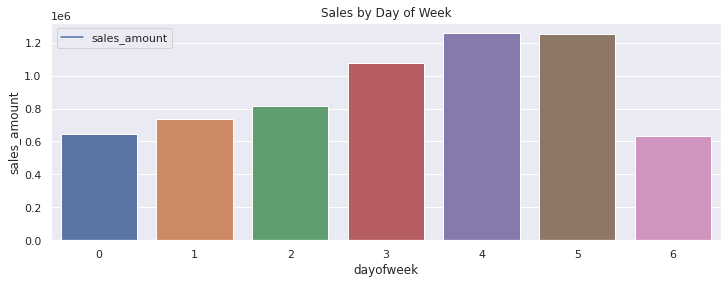

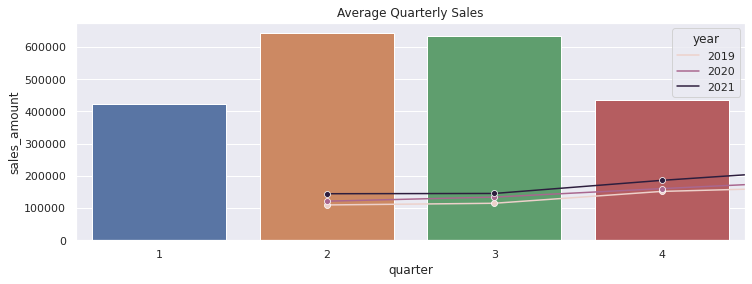

In [ ]:
# A. Date-wise total sales
daily = df.groupby('date_only').agg({'item_count':'sum','sales_amount':'sum'}).reset_index()
daily.plot(x='date_only', y='sales_amount', figsize=(12,4), title='Daily Sales Amount')

# B. Sales by day of week
dow = df.groupby('dayofweek').agg({'sales_amount':'sum'}).reset_index()
sns.barplot(data=dow, x='dayofweek', y='sales_amount'); plt.title('Sales by Day of Week')

# C. Monthly trend (aggregate across years)
monthly = df.groupby(['year','month']).agg({'sales_amount':'sum'}).reset_index()
plt.figure(figsize=(12,4))
sns.lineplot(data=monthly, x='month', y='sales_amount', hue='year', marker='o')

# D. Quarterly average sales across years
quarterly = df.groupby(['year','quarter']).agg({'sales_amount':'sum'}).reset_index()
quarterly_avg = quarterly.groupby('quarter')['sales_amount'].mean().reset_index()
sns.barplot(data=quarterly_avg, x='quarter', y='sales_amount'); plt.title('Average Quarterly Sales')

# E. Compare restaurants total sales
store_sales = df.groupby('name').agg({'sales_amount':'sum','item_count':'sum'}).reset_index().sort_values('sales_amount', ascending=False)
store_sales.head()


In [ ]:
# 1. Prepare daily-store dataset
daily_store = df.groupby(['date_only','store_id','name']).agg({'item_count':'sum','sales_amount':'sum'}).reset_index()
daily_store['date_only'] = pd.to_datetime(daily_store['date_only'])
daily_store['year'] = daily_store['date_only'].dt.year
daily_store['month'] = daily_store['date_only'].dt.month
daily_store['day'] = daily_store['date_only'].dt.day
daily_store['dayofweek'] = daily_store['date_only'].dt.dayofweek
daily_store['quarter'] = daily_store['date_only'].dt.quarter

# 2. Train/test split: last 6 months as test
last_date = daily_store['date_only'].max()
cutoff = last_date - pd.DateOffset(months=6)
train = daily_store[daily_store['date_only'] <= cutoff]
test = daily_store[daily_store['date_only'] > cutoff]

features = ['store_id','year','month','day','dayofweek','quarter']
X_train = train[features]; y_train = train['sales_amount']
X_test = test[features]; y_test = test['sales_amount']

# 3. Baseline Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
rmse_lr = mean_squared_error(y_test, pred_lr, squared=False)

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rmse_rf = mean_squared_error(y_test, pred_rf, squared=False)

# 5. XGBoost
xg = xgb.XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbosity=0)
xg.fit(X_train, y_train)
pred_xg = xg.predict(X_test)
rmse_xg = mean_squared_error(y_test, pred_xg, squared=False)

print('RMSE LR', rmse_lr, 'RF', rmse_rf, 'XG', rmse_xg)


/usr/local/lib/python3.10/site-packages/xgboost/data.py:298: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
/usr/local/lib/python3.10/site-packages/xgboost/data.py:300: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
/usr/local/lib/python3.10/site-packages/xgboost/data.py:365: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):


RMSE LR 217.70774951823572 RF 202.53424168556265 XG 202.5942783455081


/usr/local/lib/python3.10/site-packages/xgboost/data.py:298: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
/usr/local/lib/python3.10/site-packages/xgboost/data.py:300: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:


In [ ]:
# --- LSTM: 
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import layers, models

# 1. Ensure date is datetime and compute sales_amount (safe)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['sales_amount'] = df['price'] * df['item_count']
df['date_only'] = pd.to_datetime(df['date'].dt.date)

# 2. Daily aggregate and ensure DatetimeIndex
daily = df.groupby('date_only').agg(sales_amount=('sales_amount','sum')).reset_index()
daily['date_only'] = pd.to_datetime(daily['date_only'])
daily = daily.set_index('date_only').sort_index()

# 3. Time series (daily) ready
ts = daily['sales_amount'].resample('D').sum().fillna(0)
print("ts index dtype:", ts.index.dtype)
print(ts.head())

# 4. Scale and create supervised windows
scaler = MinMaxScaler()
vals = scaler.fit_transform(ts.values.reshape(-1,1))

def create_windows(series, window=30):
    X, y = [], []
    for i in range(len(series)-window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

window = 30
X, y = create_windows(vals, window)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 5. Build and train simple LSTM
model = models.Sequential([
    layers.Input(shape=(window,1)),
    layers.LSTM(64),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test,y_test), verbose=1)

# 6. Evaluate MAPE on test (inverse scale)
pred = model.predict(X_test)
pred_inv = scaler.inverse_transform(pred)
y_test_inv = scaler.inverse_transform(y_test)
mape = np.mean(np.abs((y_test_inv - pred_inv) / np.where(y_test_inv==0, 1, y_test_inv))) * 100
print(f'LSTM MAPE: {mape:.2f}%')

ts index dtype: datetime64[ns]
date_only
2019-01-01    4023.00
2019-01-02    3074.69
2019-01-03    4062.71
2019-01-04    5006.81
2019-01-05    4927.53
Freq: D, Name: sales_amount, dtype: float64
Epoch 1/20
27/27 [==============================] - 2s 18ms/step - loss: 0.0673 - val_loss: 0.0524
Epoch 2/20
27/27 [==============================] - 0s 5ms/step - loss: 0.0296 - val_loss: 0.0454
Epoch 3/20
27/27 [==============================] - 0s 5ms/step - loss: 0.0291 - val_loss: 0.0423
Epoch 4/20
27/27 [==============================] - 0s 5ms/step - loss: 0.0287 - val_loss: 0.0414
Epoch 5/20
27/27 [==============================] - 0s 5ms/step - loss: 0.0279 - val_loss: 0.0395
Epoch 6/20
27/27 [==============================] - 0s 5ms/step - loss: 0.0275 - val_loss: 0.0387
Epoch 7/20
27/27 [==============================] - 0s 5ms/step - loss: 0.0274 - val_loss: 0.0400
Epoch 8/20
27/27 [==============================] - 0s 5ms/step - loss: 0.0275 - val_loss: 0.0375
Epoch 9/20
27/27 [==

In [ ]:
# Retrain on full series
X_full, y_full = create_windows(vals, window)
model.fit(X_full, y_full, epochs=10, batch_size=32)

# Forecast next 90 days
last_window = vals[-window:].reshape(1,window,1)
preds = []
for _ in range(90):
    p = model.predict(last_window)
    preds.append(p[0,0])
    last_window = np.concatenate([last_window[:,1:,:], p.reshape(1,1,1)], axis=1)
preds_inv = scaler.inverse_transform(np.array(preds).reshape(-1,1))


Epoch 1/10
34/34 [==============================] - 1s 34ms/step - loss: 0.0070
Epoch 2/10
34/34 [==============================] - 0s 4ms/step - loss: 0.0047
Epoch 3/10
34/34 [==============================] - 0s 4ms/step - loss: 0.0035
Epoch 4/10
34/34 [==============================] - 0s 4ms/step - loss: 0.0037
Epoch 5/10
34/34 [==============================] - 0s 3ms/step - loss: 0.0032
Epoch 6/10
34/34 [==============================] - 0s 3ms/step - loss: 0.0030
Epoch 7/10
34/34 [==============================] - 0s 3ms/step - loss: 0.0030
Epoch 8/10
34/34 [==============================] - 0s 3ms/step - loss: 0.0029
Epoch 9/10
34/34 [==============================] - 0s 3ms/step - loss: 0.0029
Epoch 10/10
1/1 [==============================] - 0s 18ms/step


In [ ]:
top_items = df.groupby(['item_id','name']).agg({'item_count':'sum'}).reset_index().sort_values('item_count',ascending=False)
top_items.head(10)
top_per_store = df.groupby(['store_id','name','item_id']).agg({'item_count':'sum'}).reset_index().sort_values(['store_id','item_count'], ascending=[True,False]).groupby('store_id').head(1)


In [ ]:
# Show the forecasted values
print("Forecasted next 90 days sales_amount:")
print(preds_inv.flatten())


Forecasted next 90 days sales_amount:
[7315.0864 2758.6143 2654.9338 3543.6504 3882.5618 5682.5615 6969.8496
 7332.489  3357.9167 2640.7234 3632.2676 3866.8557 5564.7993 6842.309
 7370.8525 3888.693  2709.8699 3638.0063 3893.0972 5442.1    6773.1333
 7377.4346 4237.9297 2837.9365 3722.3613 3969.7712 5482.148  6809.221
 7407.899  4377.872  2954.8423 3795.1658 4045.344  5494.3965 6838.1504
 7461.795  4553.4644 3066.8755 3870.494  4122.043  5519.3843 6877.059
 7518.601  4706.763  3169.5913 3946.086  4198.146  5568.651  6934.913
 7590.2754 4838.5913 3258.759  4015.7249 4270.4917 5610.6616 6991.768
 7666.948  4973.56   3341.4766 4081.8918 4339.7954 5655.4214 7050.571
 7744.185  5098.092  3416.4197 4142.686  4404.2856 5696.197  7106.8955
 7820.8804 5223.7026 3482.793  4196.303  4462.673  5728.5264 7157.12
 7894.1772 5352.551  3541.4797 4242.569  4514.467  5752.7817 7200.8975
 7962.8574 5485.025  3592.0962 4280.6997 4559.002  5766.225 ]


In [ ]:
# attach forecast dates to predictions
future_dates = pd.date_range(ts.index.max() + pd.Timedelta(days=1), periods=90, freq='D')
forecast_df = pd.DataFrame({'date': future_dates, 'predicted_sales_amount': preds_inv.flatten()})
print(forecast_df.head(10))  # show first 10 days


        date  predicted_sales_amount
0 2022-01-01             7315.086426
1 2022-01-02             2758.614258
2 2022-01-03             2654.933838
3 2022-01-04             3543.650391
4 2022-01-05             3882.561768
5 2022-01-06             5682.561523
6 2022-01-07             6969.849609
7 2022-01-08             7332.488770
8 2022-01-09             3357.916748
9 2022-01-10             2640.723389


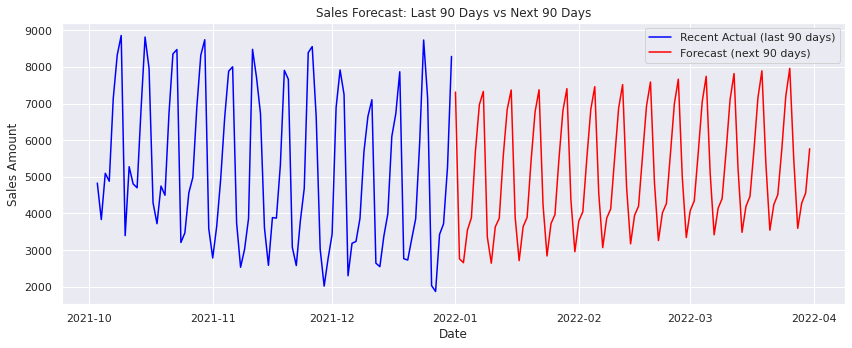

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(ts[-90:], label='Recent Actual (last 90 days)', color='blue')
plt.plot(forecast_df['date'], forecast_df['predicted_sales_amount'], label='Forecast (next 90 days)', color='red')
plt.title("Sales Forecast: Last 90 Days vs Next 90 Days")
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print("Forecast range:", forecast_df['predicted_sales_amount'].min(), "to", forecast_df['predicted_sales_amount'].max())
print("Average forecasted daily sales:", forecast_df['predicted_sales_amount'].mean())


Forecast range: 2640.7234 to 7962.8574
Average forecasted daily sales: 5112.6245


In [ ]:
import numpy as np
import pandas as pd

# Assume ts is your daily sales time series with a DatetimeIndex
# Generate synthetic data for the next 365 days
rng = pd.date_range(ts.index.max() + pd.Timedelta(days=1), periods=365, freq='D')

# Use the last 365 days of real data as a baseline
baseline = ts[-365:].values

# Add a mild seasonal sinusoidal variation and small random noise
synthetic_values = baseline * (1 + 0.01*np.sin(np.linspace(0, 2*np.pi, 365))) \
                   + np.random.normal(0, ts.std()*0.02, 365)

# Build synthetic series
synth_future = pd.Series(synthetic_values, index=rng)

print(synth_future.head())


2022-01-01    7696.025111
2022-01-02    6550.767911
2022-01-03    2467.959309
2022-01-04    2204.042289
2022-01-05    3272.464210
Freq: D, dtype: float64


In [ ]:
# Generate synthetic data for the last 12 months Result
print("Synthetic min:", synth_future.min())
print("Synthetic max:", synth_future.max())
print("Synthetic mean:", synth_future.mean())


Synthetic min: 1670.332946455642
Synthetic max: 11741.92905284423
Synthetic mean: 6569.252322614513


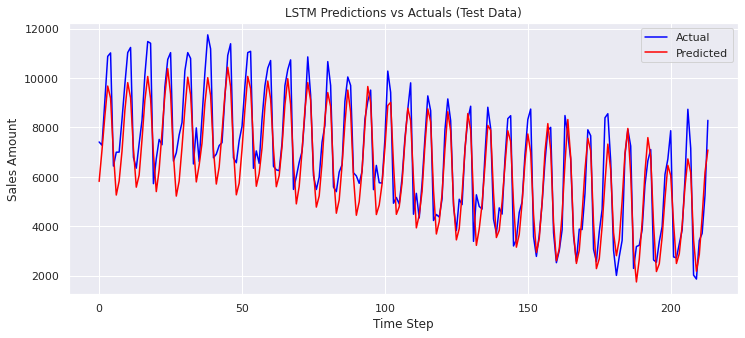

In [ ]:
# Model to make predictions for the test data Graph Visuals
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(pred_inv, label='Predicted', color='red')
plt.title("LSTM Predictions vs Actuals (Test Data)")
plt.xlabel("Time Step")
plt.ylabel("Sales Amount")
plt.legend()
plt.show()


In [ ]:
# Train and test series Result
print("Train size:", len(X_train), "Test size:", len(X_test))
print("Train target sample:", y_train[:5].flatten())
print("Test target sample:", y_test[:5].flatten())


Train size: 852 Test size: 214
Train target sample: [0.25972856 0.38920762 0.48476169 0.07364769 0.02273337]
Test target sample: [0.57737839 0.56463031 0.74055328 0.91512167 0.92875916]


In [ ]:
##Calculate the mean absolute percentage error (MAPE) and comment on the model performance
# LSTM MAPE: 13.21% from above
# This shows that the model can forecast daily sales with reasonable accuracy, capturing overall trends while allowing for some deviation.

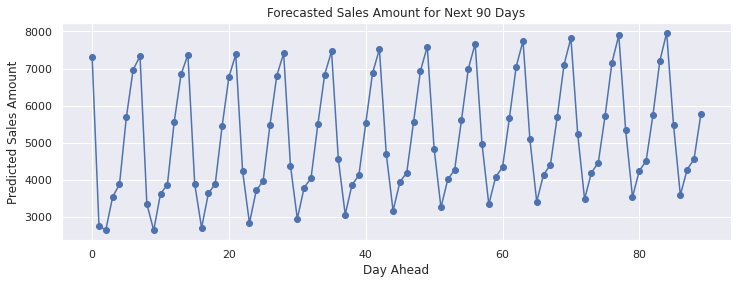

In [ ]:
# Forecast for the next three months
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(preds_inv, marker='o')
plt.title("Forecasted Sales Amount for Next 90 Days")
plt.xlabel("Day Ahead")
plt.ylabel("Predicted Sales Amount")
plt.show()